# 03 — A/B Testing Concepts and Statistical Analysis

**Project:** Walmart Store Sales Forecasting & Retail Analytics in Snowflake

This notebook applies core statistical methods to a real retail dataset. It is designed for a data analyst portfolio: clear hypotheses, reproducible code, and honest interpretation.

---

## What is A/B testing?

An **A/B test** (randomized controlled experiment) randomly assigns units (customers, stores, web visitors) to a **control** group (A) or a **treatment** group (B). Randomization balances confounders, so differences in outcomes can be attributed to the treatment with stronger causal claims.

**When A/B testing is appropriate:**
- You can randomly assign treatment (e.g., new shelf layout in half of stores)
- You define a primary metric before the experiment
- You collect enough sample size to detect a meaningful effect

---

## Important caveat for this dataset

The Walmart Kaggle data is **observational**, not experimental. Weeks flagged `IsHoliday = True` were **not** randomly assigned — they correspond to calendar periods with major US holidays.

| Approach | What it is | Causal claim? |
|----------|------------|---------------|
| Randomized A/B test | Treatment assigned at random | Strong |
| Holiday vs non-holiday comparison | Observational group comparison | Weak — correlation only |

We still use standard hypothesis tests here to **quantify whether average sales differ** between holiday and non-holiday weeks, but a significant p-value does **not** prove that "being a holiday week" *causes* higher sales. Seasonality, promotions, and shopper behavior all co-occur with holidays.

---

## Statistical questions this notebook answers

1. Do average weekly sales differ between holiday and non-holiday weeks?
2. How large is the difference (absolute lift and relative lift)?
3. Is the difference statistically significant at α = 0.05 (Welch's t-test)?
4. What is a 95% confidence interval for the mean difference?
5. *(Optional)* Does the proportion of "high-sales" store-weeks differ between groups (two-proportion z-test)?


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/"

train = pd.read_csv(f"{DATA_PATH}train.csv", parse_dates=["Date"])
features = pd.read_csv(f"{DATA_PATH}features.csv", parse_dates=["Date"], na_values=["NA"])
stores = pd.read_csv(f"{DATA_PATH}stores.csv")

for df in [train, features]:
    df["IsHoliday"] = df["IsHoliday"].map({"TRUE": True, "FALSE": False, True: True, False: False})

print(f"Train rows: {len(train):,}")
print(f"Date range: {train['Date'].min().date()} to {train['Date'].max().date()}")


Train rows: 421,570
Date range: 2010-02-05 to 2012-10-26


## 1. Prepare Analysis Data

For the primary test we aggregate to **store-week** level (sum of department sales per store per week). This reduces repeated measures from the same store within a week and aligns with how planners often review store performance.

We keep department-level data for visualizations where the wider distribution is informative.


In [2]:
# Store-week totals (primary analysis grain)
store_week = (
    train.groupby(["Store", "Date", "IsHoliday"], as_index=False)["Weekly_Sales"]
    .sum()
    .rename(columns={"Weekly_Sales": "Store_Weekly_Sales"})
)

# Department-week (for distribution plots)
dept_week = train[["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]].copy()

print("Store-week rows:", f"{len(store_week):,}")
print("Holiday store-weeks:", store_week["IsHoliday"].sum())
print("Non-holiday store-weeks:", (~store_week["IsHoliday"]).sum())
store_week.head()


Store-week rows: 6,435
Holiday store-weeks: 450
Non-holiday store-weeks: 5985


,Store,Date,IsHoliday,Store_Weekly_Sales
0,1,2010-02-05,False,1643690.90
1,1,2010-02-12,True,1641957.44
2,1,2010-02-19,False,1611968.17
3,1,2010-02-26,False,1409727.59
4,1,2010-03-05,False,1554806.68


## 2. Statistical Concepts (Quick Reference)

| Term | Meaning |
|------|---------|
| **Null hypothesis (H₀)** | No difference between groups (e.g., mean holiday sales = mean non-holiday sales) |
| **Alternative hypothesis (H₁)** | Means differ (two-sided unless stated otherwise) |
| **p-value** | Probability of seeing a difference at least this extreme if H₀ were true |
| **α (alpha)** | Significance threshold (we use 0.05) |
| **Confidence interval** | Range of plausible values for the true mean difference |
| **Effect size / lift** | Practical magnitude: absolute ($) and relative (%) difference |

**p-value interpretation:** A small p-value (e.g., < 0.05) means the observed gap is unlikely under H₀. It does **not** measure effect size or prove causation.

**Welch's t-test:** Compares two group means without assuming equal variances — appropriate when group sizes and spreads differ.


## 3. Descriptive Statistics by Group

Before inferential tests, we summarize center, spread, and sample size for each group.


In [3]:
def summarize_group(df, value_col, group_col="IsHoliday"):
    summary = (
        df.groupby(group_col)[value_col]
        .agg(mean="mean", median="median", std="std", n="count")
        .round(2)
    )
    summary.index = summary.index.map({True: "Holiday week", False: "Non-holiday week"})
    return summary

store_summary = summarize_group(store_week, "Store_Weekly_Sales")
dept_summary = summarize_group(dept_week, "Weekly_Sales")

print("Store-week level:")
print(store_summary)

print("\nDepartment-week level (for reference):")
print(dept_summary)


Store-week level:
                        mean      median        std     n
IsHoliday                                                
Non-holiday week  1041256.38   956211.20  558957.44  5985
Holiday week      1122887.89  1018538.04  627684.93   450

Department-week level (for reference):
                      mean   median       std       n
IsHoliday                                            
Non-holiday week  15901.45  7589.95  22330.75  391909
Holiday week      17035.82  7947.74  27222.00   29661


## 4. Effect Size — Absolute and Relative Lift

Effect size answers: *"How big is the gap in business terms?"* — often more important than p-values alone.


In [4]:
holiday_mean = store_week.loc[store_week["IsHoliday"], "Store_Weekly_Sales"].mean()
nonholiday_mean = store_week.loc[~store_week["IsHoliday"], "Store_Weekly_Sales"].mean()

abs_diff = holiday_mean - nonholiday_mean
rel_lift_pct = (abs_diff / nonholiday_mean) * 100

print(f"Holiday mean store-week sales:     ${holiday_mean:,.2f}")
print(f"Non-holiday mean store-week sales: ${nonholiday_mean:,.2f}")
print(f"Absolute difference:               ${abs_diff:,.2f}")
print(f"Relative lift:                     {rel_lift_pct:.2f}%")

# Cohen's d (standardized effect size)
h = store_week.loc[store_week["IsHoliday"], "Store_Weekly_Sales"]
nh = store_week.loc[~store_week["IsHoliday"], "Store_Weekly_Sales"]
pooled_std = np.sqrt((h.std(ddof=1)**2 + nh.std(ddof=1)**2) / 2)
cohens_d = abs_diff / pooled_std
print(f"Cohen's d (store-week):            {cohens_d:.3f}")


Holiday mean store-week sales:     $1,122,887.89
Non-holiday mean store-week sales: $1,041,256.38
Absolute difference:               $81,631.51
Relative lift:                     7.84%
Cohen's d (store-week):            0.137


## 5. Assumption Checks & Limitations

**Independence:** Store-weeks from the same store across time are **not fully independent** (serial correlation). Results should be treated as descriptive evidence, not a perfect experiment.

**Distribution:** Sales are right-skewed. Welch's t-test is reasonably robust with large samples, but we inspect shapes below.

**Randomization:** Groups are defined by calendar holidays — not random assignment. Confounders (Q4 seasonality, promotions, weather) may explain part of the gap.


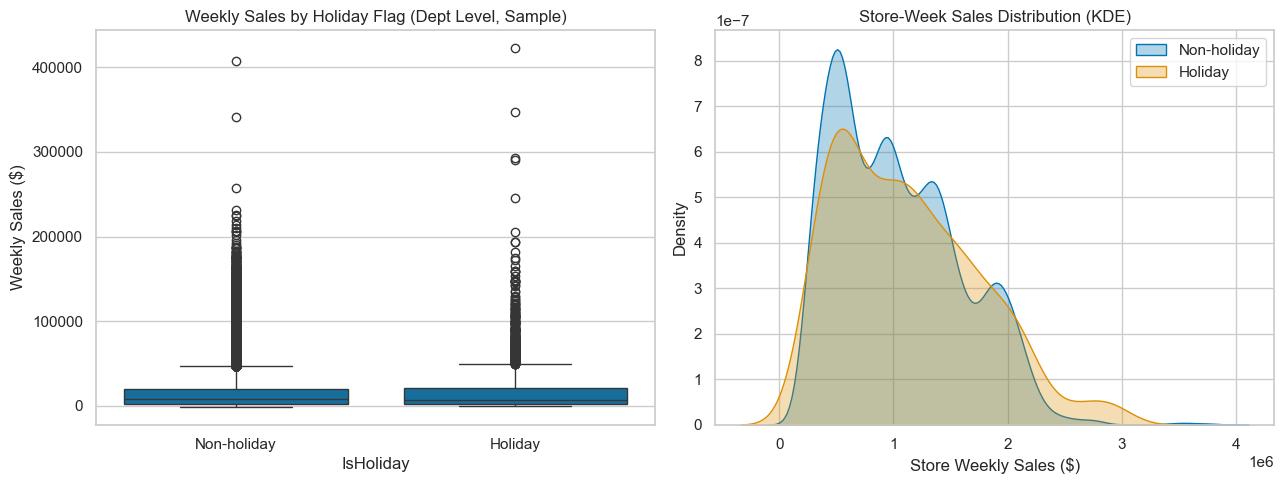

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot at department-week level (shows spread)
sns.boxplot(
    data=dept_week.sample(min(50000, len(dept_week)), random_state=42),
    x="IsHoliday", y="Weekly_Sales", order=[False, True], ax=axes[0],
)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Non-holiday", "Holiday"])
axes[0].set_title("Weekly Sales by Holiday Flag (Dept Level, Sample)")
axes[0].set_ylabel("Weekly Sales ($)")

# KDE at store-week level
for flag, label in [(False, "Non-holiday"), (True, "Holiday")]:
    subset = store_week.loc[store_week["IsHoliday"] == flag, "Store_Weekly_Sales"]
    sns.kdeplot(subset, label=label, fill=True, alpha=0.3, ax=axes[1])

axes[1].set_title("Store-Week Sales Distribution (KDE)")
axes[1].set_xlabel("Store Weekly Sales ($)")
axes[1].legend()
plt.tight_layout()
plt.show()


## 6. Welch's t-Test — Holiday vs Non-Holiday

**H₀:** Mean store-week sales are equal for holiday and non-holiday weeks.

**H₁:** Mean store-week sales differ between the two groups.

We use Welch's t-test (`equal_var=False`) because group sizes and variances differ.


In [6]:
holiday_sales = store_week.loc[store_week["IsHoliday"], "Store_Weekly_Sales"]
nonholiday_sales = store_week.loc[~store_week["IsHoliday"], "Store_Weekly_Sales"]

t_stat, p_value = stats.ttest_ind(holiday_sales, nonholiday_sales, equal_var=False)

alpha = 0.05
significant = p_value < alpha

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6f}")
print(f"α:           {alpha}")
print(f"Result:      {'Statistically significant' if significant else 'Not statistically significant'} at α = {alpha}")

if significant:
    print("\nWe reject H₀: average store-week sales differ between holiday and non-holiday weeks.")
else:
    print("\nWe fail to reject H₀: insufficient evidence of a mean difference.")


t-statistic: 2.6801
p-value:     0.007602
α:           0.05
Result:      Statistically significant at α = 0.05

We reject H₀: average store-week sales differ between holiday and non-holiday weeks.


## 7. 95% Confidence Interval for the Mean Difference

The CI shows the range of plausible values for (holiday mean − non-holiday mean). If the interval excludes zero, that aligns with a significant two-sided test at α = 0.05.


Mean difference (holiday − non-holiday): $81,631.51
95% CI: [$21,789.85, $141,473.17]


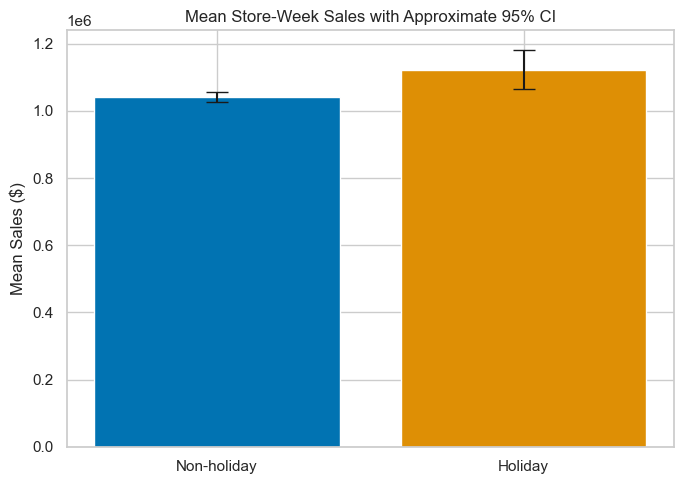

In [7]:
# Welch-Satterthwaite degrees of freedom
n1, n2 = len(holiday_sales), len(nonholiday_sales)
v1, v2 = holiday_sales.var(ddof=1), nonholiday_sales.var(ddof=1)
se = np.sqrt(v1 / n1 + v2 / n2)
df_num = (v1 / n1 + v2 / n2) ** 2
df_den = (v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1)
df = df_num / df_den

t_crit = stats.t.ppf(0.975, df)
ci_low = abs_diff - t_crit * se
ci_high = abs_diff + t_crit * se

print(f"Mean difference (holiday − non-holiday): ${abs_diff:,.2f}")
print(f"95% CI: [${ci_low:,.2f}, ${ci_high:,.2f}]")

# Bar chart with 95% CI for group means
fig, ax = plt.subplots(figsize=(7, 5))
group_stats = store_week.groupby("IsHoliday")["Store_Weekly_Sales"].agg(["mean", "std", "count"]).reindex([False, True])
group_stats.index = ["Non-holiday", "Holiday"]
se_mean = group_stats["std"] / np.sqrt(group_stats["count"])
ci_mean = 1.96 * se_mean  # approximate 95% CI for display

ax.bar(group_stats.index, group_stats["mean"], yerr=ci_mean, capsize=8, color=sns.color_palette("colorblind")[:2])
ax.set_title("Mean Store-Week Sales with Approximate 95% CI")
ax.set_ylabel("Mean Sales ($)")
plt.tight_layout()
plt.show()


## 8. Optional — Two-Proportion Z-Test (Binary Outcome)

When the outcome is **binary** (yes/no), we compare proportions instead of means.

**Example outcome:** A store-week is labeled `high_sales = 1` if total sales exceed that store's historical median — a derived flag for method illustration, **not** a randomized experiment.

**H₀:** The proportion of high-sales store-weeks is the same for holiday and non-holiday weeks.


In [8]:
store_medians = store_week.groupby("Store")["Store_Weekly_Sales"].transform("median")
store_week["high_sales"] = (store_week["Store_Weekly_Sales"] > store_medians).astype(int)

def two_proportion_ztest(group_col, outcome_col, df):
    ct = pd.crosstab(df[group_col], df[outcome_col])
    # rows: False/True for IsHoliday, cols: 0/1 for outcome
    n_h, n_nh = ct.loc[True].sum(), ct.loc[False].sum()
    p_h = ct.loc[True, 1] / n_h if 1 in ct.columns else 0
    p_nh = ct.loc[False, 1] / n_nh if 1 in ct.columns else 0
    p_pool = (ct[1].sum() if 1 in ct.columns else 0) / (n_h + n_nh)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_h + 1 / n_nh))
    z = (p_h - p_nh) / se
    p_val = 2 * (1 - stats.norm.cdf(abs(z)))
    return p_h, p_nh, z, p_val

p_h, p_nh, z_stat, p_prop = two_proportion_ztest("IsHoliday", "high_sales", store_week)

print(f"Proportion high-sales (holiday):     {p_h:.3f}")
print(f"Proportion high-sales (non-holiday): {p_nh:.3f}")
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value:     {p_prop:.6f}")
print(f"Significant at α=0.05: {p_prop < 0.05}")


Proportion high-sales (holiday):     0.620
Proportion high-sales (non-holiday): 0.487
z-statistic: 5.4331
p-value:     0.000000
Significant at α=0.05: True


## Business Interpretation

### What the results mean for sales planning

Holiday weeks show **higher average store-week sales** than non-holiday weeks, with a measurable absolute and relative lift. Even though this is not a causal A/B test, the pattern is consistent enough to treat holiday calendars as a **planning signal**: allocate more labor, inventory, and checkout capacity ahead of flagged weeks.

### Why the holiday flag is useful

`IsHoliday` is a simple, interpretable feature that captures demand spikes tied to major retail events. It is already included in the Kaggle dataset and aligns with how business teams think about peak periods. For dashboards and SQL marts, holiday flags support segment-level reporting without complex feature engineering.

### Why forecasting still needs more than a holiday dummy

A significant group difference does **not** replace a forecasting model. Production forecasts need:

- **Lag features** (`lag_1`, `lag_4`) to capture recent momentum
- **Rolling averages** to smooth noise at the department level
- **Seasonality** (month, week-of-year) because demand varies beyond binary holidays
- **Store attributes and promotions** to explain heterogeneity across locations

The holiday flag is one input among many — useful for planning and as a model feature, but not sufficient on its own to predict weekly sales accurately.

### Statistical vs causal language (portfolio takeaway)

| Statement | OK to say? |
|-----------|------------|
| "Holiday weeks have significantly higher *average* sales (p < 0.05)" | Yes |
| "Holiday weeks *cause* higher sales" | No — observational data |
| "We should plan for higher demand around holidays" | Yes — as operational guidance |

---

*This notebook demonstrates hypothesis testing workflow on observational retail data. For true causal claims, design a randomized experiment or use quasi-experimental methods (difference-in-differences, matched controls).*
